In [1]:
import sys
print(sys.executable)

c:\Users\Shivam Shekhar\FinalYearProject\venv\Scripts\python.exe


In [2]:
import pandas as pd

ratings = pd.read_csv(
    "../data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
print("Shape:", ratings.shape)
print("Unique Users:", ratings.user_id.nunique())
print("Unique Movies:", ratings.movie_id.nunique())
print("Rating Scale:", ratings.rating.unique())

Shape: (100000, 4)
Unique Users: 943
Unique Movies: 1682
Rating Scale: [3 1 2 4 5]


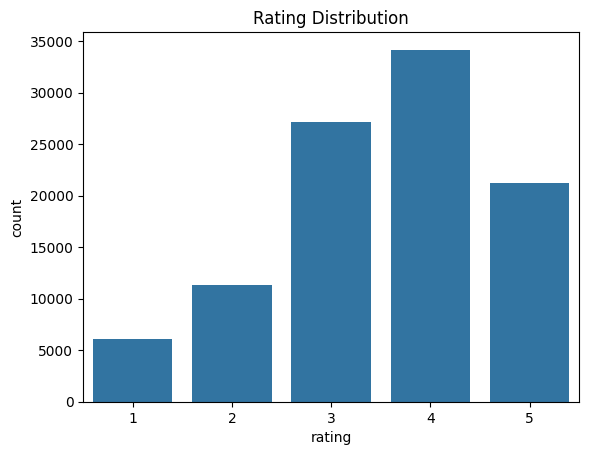

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="rating", data=ratings)
plt.title("Rating Distribution")
plt.show()

In [5]:
num_users = ratings.user_id.nunique()
num_movies = ratings.movie_id.nunique()
num_ratings = len(ratings)

total_possible = num_users * num_movies

sparsity = 1 - (num_ratings / total_possible)

print("Total Possible Ratings:", total_possible)
print("Actual Ratings:", num_ratings)
print("Sparsity:", round(sparsity * 100, 2), "%")

Total Possible Ratings: 1586126
Actual Ratings: 100000
Sparsity: 93.7 %


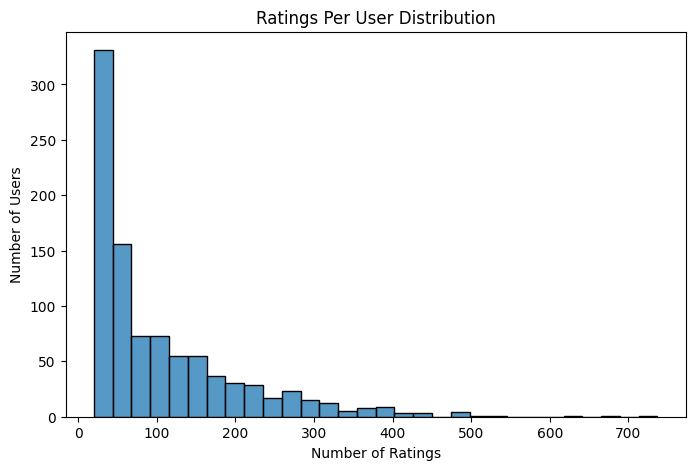

In [6]:
ratings_per_user = ratings.groupby("user_id")["rating"].count()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_user, bins=30)
plt.title("Ratings Per User Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

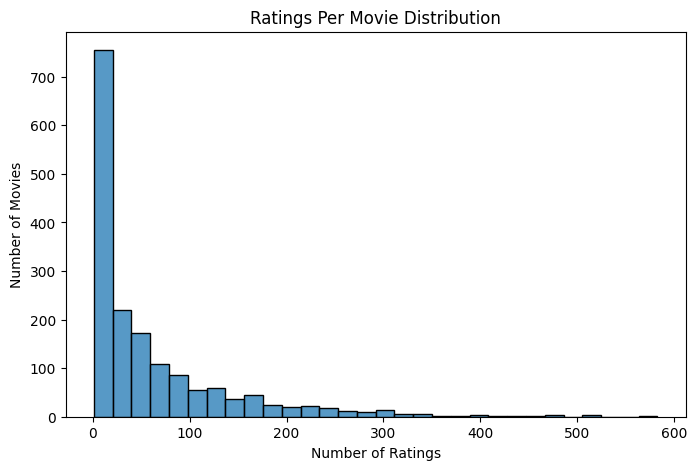

In [7]:
ratings_per_movie = ratings.groupby("movie_id")["rating"].count()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_movie, bins=30)
plt.title("Ratings Per Movie Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

In [8]:
import os
os.getcwd()

'c:\\Users\\Shivam Shekhar\\FinalYearProject\\notebooks'

In [9]:
# =========================================
# USER-BASED COLLABORATIVE FILTERING SETUP
# =========================================

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# 1️⃣ Load Ratings Dataset
# -------------------------------
ratings = pd.read_csv(
    "../data/ml-100k/u.data",  # from notebooks folder, go up one level
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print("Dataset loaded successfully!")
print("Shape:", ratings.shape)
print("Unique Users:", ratings.user_id.nunique())
print("Unique Movies:", ratings.movie_id.nunique())

# -------------------------------
# 2️⃣ Create User-Item Matrix
# -------------------------------
user_item_matrix = ratings.pivot(
    index="user_id",
    columns="movie_id",
    values="rating"
)
print("\nUser-Item Matrix created!")
print("Shape:", user_item_matrix.shape)
user_item_matrix.head()

# -------------------------------
# 3️⃣ Fill NaN with 0
# -------------------------------
user_item_filled = user_item_matrix.fillna(0)
print("\nNaN values replaced with 0 for similarity computation.")
user_item_filled.head()

# -------------------------------
# 4️⃣ Compute User Similarity (Cosine)
# -------------------------------
user_similarity = cosine_similarity(user_item_filled)
print("\nUser similarity matrix computed!")
print("Shape:", user_similarity.shape)

# Convert to DataFrame for easier lookup
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)
print("\nUser similarity DataFrame ready!")
user_similarity_df.head()

# -------------------------------
# ✅ READY FOR RECOMMENDATIONS
# -------------------------------
# At this point:
# - user_item_filled = user-item matrix with zeros
# - user_similarity_df = 943x943 matrix with similarity scores
# Next step: pick a user, find top similar users, recommend unseen movies

Dataset loaded successfully!
Shape: (100000, 4)
Unique Users: 943
Unique Movies: 1682

User-Item Matrix created!
Shape: (943, 1682)

NaN values replaced with 0 for similarity computation.

User similarity matrix computed!
Shape: (943, 943)

User similarity DataFrame ready!


user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


In [10]:
def recommend_movies_titles(user_id, user_item_filled, user_similarity_df, movies_df, top_n_sim_users=5, top_n_movies=5):
    """
    Recommend movies with titles for a given user using User-Based Collaborative Filtering.
    """
    recommended_ids = recommend_movies(
        user_id, user_item_filled, user_similarity_df,
        top_n_sim_users=top_n_sim_users,
        top_n_movies=top_n_movies
    )
    
    # Map movie IDs to titles
    recommended_titles = movies_df[movies_df.movie_id.isin(recommended_ids)]["title"].tolist()
    
    return recommended_titles

In [11]:
# =============================================
# LOAD MOVIE TITLES
# =============================================

import pandas as pd

# Path to movie info file
movie_path = "../data/ml-100k/u.item"

# Load movie data
movies = pd.read_csv(
    movie_path,
    sep="|",
    encoding="latin-1",  # important for special characters
    header=None,
    names=[
        "movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
        "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
        "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
        "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
    ]
)

# Keep only movie_id and title
movies = movies[["movie_id", "title"]]
movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


Popularity-Based Recommender

Top 10 Most Popular Movies:
                           title  num_ratings
0               Star Wars (1977)          583
1                 Contact (1997)          509
2                   Fargo (1996)          508
3      Return of the Jedi (1983)          507
4               Liar Liar (1997)          485
5    English Patient, The (1996)          481
6                  Scream (1996)          478
7               Toy Story (1995)          452
8           Air Force One (1997)          431
9  Independence Day (ID4) (1996)          429


C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_3884\4199733032.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


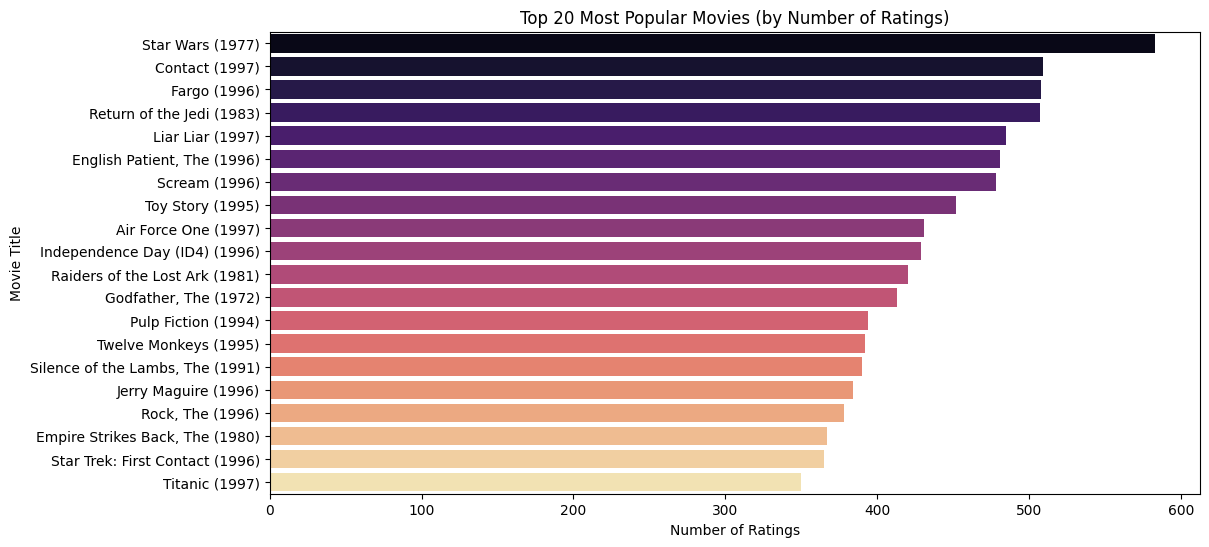


Top 5 Popular Movies Recommended:
1. Star Wars (1977)
2. Contact (1997)
3. Fargo (1996)
4. Return of the Jedi (1983)
5. Liar Liar (1997)


In [12]:
# ================================
# POPULARITY-BASED RECOMMENDER
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Count total ratings per movie
movie_rating_counts = ratings.groupby("movie_id")["rating"].count().sort_values(ascending=False)

# 2️⃣ Merge with movie titles
popular_movies = pd.merge(
    movie_rating_counts.reset_index(),
    movies,
    on="movie_id"
)

popular_movies.rename(columns={"rating": "num_ratings"}, inplace=True)

# 3️⃣ Show top 10 popular movies
print("Top 10 Most Popular Movies:")
print(popular_movies[["title", "num_ratings"]].head(10))

# 4️⃣ Plot top 20 popular movies
plt.figure(figsize=(12,6))
sns.barplot(
    x="num_ratings",
    y="title",
    data=popular_movies.head(20),
    palette="magma"
)
plt.title("Top 20 Most Popular Movies (by Number of Ratings)")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()

# 5️⃣ Popularity-based recommender function
def recommend_popular_movies(top_n=5):
    """
    Recommend top-N popular movies to any user
    """
    return popular_movies["title"].head(top_n).tolist()

# Example: Recommend 5 movies
top_popular = recommend_popular_movies(5)
print("\nTop 5 Popular Movies Recommended:")
for i, title in enumerate(top_popular, 1):
    print(f"{i}. {title}")

In [13]:
# Movie-User Matrix
movie_user_matrix = ratings.pivot(
    index="movie_id",
    columns="user_id",
    values="rating"
)

# Fill NaN values with 0 for similarity computation
movie_user_filled = movie_user_matrix.fillna(0)

print("Movie-User Matrix Shape:", movie_user_filled.shape)
movie_user_filled.head()

Movie-User Matrix Shape: (1682, 943)


user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
movie_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,4.0,...,2.0,3.0,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0
2,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,...,5.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Compute cosine similarity between movies
item_similarity = cosine_similarity(movie_user_filled)

# Convert to DataFrame for easier lookup
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=movie_user_filled.index,
    columns=movie_user_filled.index
)

print("Item Similarity Matrix Shape:", item_similarity_df.shape)
item_similarity_df.head()

Item Similarity Matrix Shape: (1682, 1682)


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
movie_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714,0.116344,0.620979,0.481114,0.496288,0.273935,...,0.035387,0.0,0.000000,0.000000,0.035387,0.0,0.0,0.0,0.047183,0.047183
2,0.402382,1.000000,0.273069,0.502571,0.318836,0.083563,0.383403,0.337002,0.255252,0.171082,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.078299,0.078299
3,0.330245,0.273069,1.000000,0.324866,0.212957,0.106722,0.372921,0.200794,0.273669,0.158104,...,0.000000,0.0,0.000000,0.000000,0.032292,0.0,0.0,0.0,0.000000,0.096875
4,0.454938,0.502571,0.324866,1.000000,0.334239,0.090308,0.489283,0.490236,0.419044,0.252561,...,0.000000,0.0,0.094022,0.094022,0.037609,0.0,0.0,0.0,0.056413,0.075218
5,0.286714,0.318836,0.212957,0.334239,1.000000,0.037299,0.334769,0.259161,0.272448,0.055453,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.094211


In [15]:
def recommend_movies_item_cf(user_id, movie_user_filled, item_similarity_df, top_n_movies=5):
    """
    Recommend movies for a user using Item-Based Collaborative Filtering
    """
    # Movies already rated by user
    user_ratings = movie_user_filled[user_id]
    rated_movies = user_ratings[user_ratings > 0].index.tolist()
    
    # Dictionary to store predicted scores
    movie_scores = {}
    
    for movie in rated_movies:
        # Get similarity for this movie with all other movies
        sim_movies = item_similarity_df[movie]
        
        for sim_movie, score in sim_movies.items():
            if sim_movie in rated_movies:
                continue  # skip already rated
            if sim_movie not in movie_scores:
                movie_scores[sim_movie] = 0
            movie_scores[sim_movie] += score * user_ratings[movie]
    
    # Sort movies by score
    recommended_movies = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)
    recommended_movie_ids = [movie for movie, score in recommended_movies[:top_n_movies]]
    
    return recommended_movie_ids

In [16]:
def recommend_movies_item_cf_titles(user_id, movie_user_filled, item_similarity_df, movies_df, top_n_movies=5):
    movie_ids = recommend_movies_item_cf(user_id, movie_user_filled, item_similarity_df, top_n_movies)
    recommended_titles = movies_df[movies_df.movie_id.isin(movie_ids)]["title"].tolist()
    return recommended_titles

In [17]:
user_id_example = 1
recommended_titles_item = recommend_movies_item_cf_titles(
    user_id_example,
    movie_user_filled,
    item_similarity_df,
    movies
)

print(f"Top 5 Item-Based CF Recommendations for User {user_id_example}:")
for i, title in enumerate(recommended_titles_item, 1):
    print(f"{i}. {title}")

Top 5 Item-Based CF Recommendations for User 1:
1. True Lies (1994)
2. Batman (1989)
3. E.T. the Extra-Terrestrial (1982)
4. Speed (1994)
5. Stand by Me (1986)


Day 3: Hybrid Recommender + Basic Evaluation. 🎯

In [18]:
# Normalize popularity score
popular_movies["popularity_score"] = popular_movies["num_ratings"] / popular_movies["num_ratings"].max()

# Create dictionary for fast lookup
pop_score_dict = dict(zip(popular_movies["movie_id"], popular_movies["popularity_score"]))

# Hybrid recommendation function
def recommend_hybrid(user_id, movie_user_filled, item_similarity_df, top_n=5, alpha=0.7):
    """
    Weighted hybrid recommender combining Item-CF and popularity
    alpha = weight for personalization (Item-CF)
    """
    # Item-CF recommended movie scores
    user_ratings = movie_user_filled[user_id]
    rated_movies = user_ratings[user_ratings > 0].index.tolist()
    
    movie_scores = {}
    for movie in rated_movies:
        sim_movies = item_similarity_df[movie]
        for sim_movie, score in sim_movies.items():
            if sim_movie in rated_movies:
                continue
            if sim_movie not in movie_scores:
                movie_scores[sim_movie] = 0
            movie_scores[sim_movie] += score * user_ratings[movie]
    
    # Combine with popularity
    for movie_id in movie_scores:
        pop_score = pop_score_dict.get(movie_id, 0)
        movie_scores[movie_id] = alpha * movie_scores[movie_id] + (1 - alpha) * pop_score
    
    # Sort and pick top-N
    recommended_movies = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)
    return [movie for movie, score in recommended_movies[:top_n]]

In [19]:
def recommend_hybrid_titles(user_id, movie_user_filled, item_similarity_df, movies_df, top_n=5, alpha=0.7):
    movie_ids = recommend_hybrid(user_id, movie_user_filled, item_similarity_df, top_n, alpha)
    recommended_titles = movies_df[movies_df.movie_id.isin(movie_ids)]["title"].tolist()
    return recommended_titles

In [20]:
user_id_example = 1
recommended_titles_hybrid = recommend_hybrid_titles(
    user_id_example,
    movie_user_filled,
    item_similarity_df,
    movies,
    top_n=5,
    alpha=0.7
)

print(f"Top 5 Hybrid Recommendations for User {user_id_example}:")
for i, title in enumerate(recommended_titles_hybrid, 1):
    print(f"{i}. {title}")

Top 5 Hybrid Recommendations for User 1:
1. True Lies (1994)
2. Batman (1989)
3. E.T. the Extra-Terrestrial (1982)
4. Speed (1994)
5. Stand by Me (1986)


week 3:Adaptive / Agentic Layer for Hybrid Recommender.

In [21]:
# Activate virtual environment and select Python (FYP) kernel
# Ensure VS Code kernel is restarted before running the notebook

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

In [23]:
ratings = pd.read_csv(
    "../data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)
print("Ratings shape:", ratings.shape)
ratings.head()

Ratings shape: (100000, 4)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


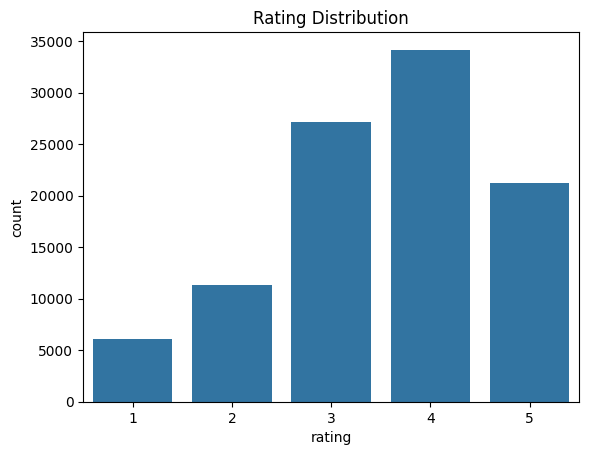

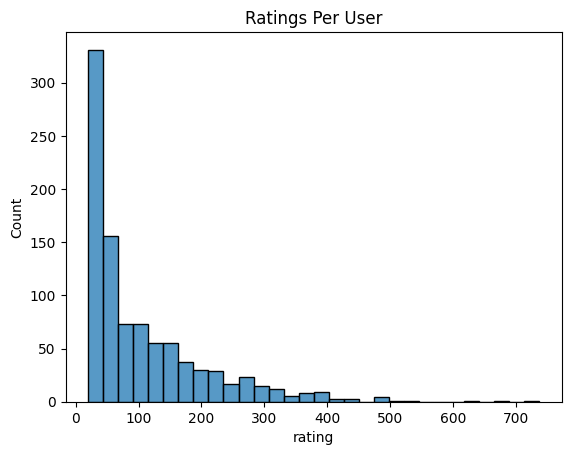

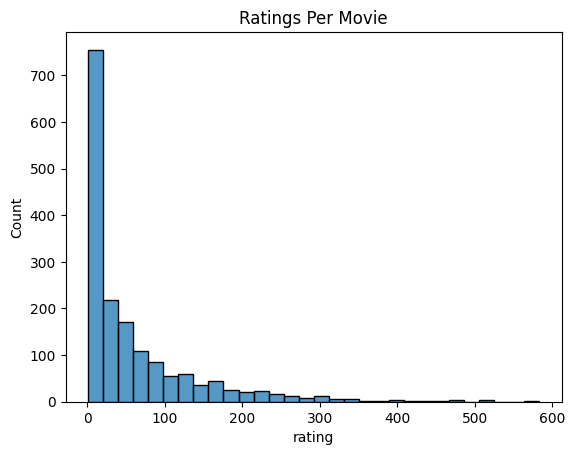

In [24]:
# Rating distribution
sns.countplot(x="rating", data=ratings)
plt.title("Rating Distribution")
plt.show()

# Ratings per user
ratings_per_user = ratings.groupby("user_id")["rating"].count()
sns.histplot(ratings_per_user, bins=30)
plt.title("Ratings Per User")
plt.show()

# Ratings per movie
ratings_per_movie = ratings.groupby("movie_id")["rating"].count()
sns.histplot(ratings_per_movie, bins=30)
plt.title("Ratings Per Movie")
plt.show()

In [25]:
user_item_matrix = ratings.pivot(index="user_id", columns="movie_id", values="rating").fillna(0)
user_item_sparse = csr_matrix(user_item_matrix.values)
print("Sparse user-item matrix shape:", user_item_sparse.shape)

Sparse user-item matrix shape: (943, 1682)


In [26]:
user_rating_counts = ratings.groupby("user_id")["rating"].count()
alpha_per_user = user_rating_counts / user_rating_counts.max()
alpha_per_user.head()

user_id
1    0.369064
2    0.084125
3    0.073270
4    0.032564
5    0.237449
Name: rating, dtype: float64

In [27]:
popular_movies = ratings.groupby("movie_id")["rating"].count().reset_index()
popular_movies.rename(columns={"rating":"num_ratings"}, inplace=True)
popular_movies["pop_score"] = popular_movies["num_ratings"] / popular_movies["num_ratings"].max()
pop_score_dict = dict(zip(popular_movies["movie_id"], popular_movies["pop_score"]))

In [28]:
user_sim_matrix = cosine_similarity(user_item_sparse)
user_sim_df = pd.DataFrame(user_sim_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)
user_sim_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


In [29]:
def recommend_hybrid_full(user_id, top_n=5, k=10):
    alpha = alpha_per_user.get(user_id, 0.5)
    similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:k+1]
    cf_scores = user_item_matrix.loc[similar_users.index].T.dot(similar_users.values) / similar_users.values.sum()
    
    combined_scores = {}
    for movie in user_item_matrix.columns:
        pop_score = pop_score_dict.get(movie, 0)
        cf_score = cf_scores.get(movie, 0)
        combined_scores[movie] = alpha * cf_score + (1-alpha) * pop_score
    
    # Filter already-rated movies
    rated_movies = set(ratings[ratings.user_id == user_id]["movie_id"])
    recommended = [(m,s) for m,s in combined_scores.items() if m not in rated_movies]
    
    top_movies = [m for m,s in sorted(recommended, key=lambda x: x[1], reverse=True)[:top_n]]
    return top_movies

In [30]:
user_id_example = 1
top_movies_full = recommend_hybrid_full(user_id_example, top_n=5, k=10)
print(f"Top 5 Hybrid Movies for User {user_id_example}: {top_movies_full}")

Top 5 Hybrid Movies for User 1: [318, 423, 288, 474, 357]


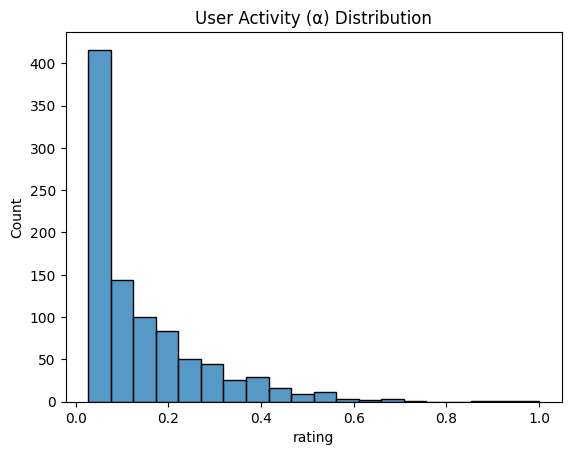

In [31]:
# α distribution
sns.histplot(alpha_per_user, bins=20)
plt.title("User Activity (α) Distribution")
plt.show()

In [32]:
# Count number of ratings per movie
popular_movies = ratings.groupby("movie_id")["rating"].count().reset_index()

# Rename column for clarity
popular_movies.rename(columns={"rating":"num_ratings"}, inplace=True)

# Normalize popularity to [0,1]
popular_movies["pop_score"] = popular_movies["num_ratings"] / popular_movies["num_ratings"].max()

# Create a dictionary for fast lookup
pop_score_dict = dict(zip(popular_movies["movie_id"], popular_movies["pop_score"]))

# Optional: check top 5 popular movies
popular_movies.sort_values("pop_score", ascending=False).head()

,movie_id,num_ratings,pop_score
49,50,583,1.000000
257,258,509,0.873070
99,100,508,0.871355
180,181,507,0.869640
293,294,485,0.831904


In [33]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Convert full user-item matrix to sparse matrix to save memory
user_item_sparse = csr_matrix(user_item_matrix.values)

# Compute cosine similarity between users
user_sim_matrix = cosine_similarity(user_item_sparse)

# Convert similarity matrix to DataFrame for easy access
user_sim_df = pd.DataFrame(user_sim_matrix, 
                           index=user_item_matrix.index, 
                           columns=user_item_matrix.index)

# Check first 5 rows
user_sim_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


In [34]:
def recommend_hybrid_full(user_id, top_n=5, k=10):
    """
    Hybrid recommender for full dataset.
    
    Parameters:
    - user_id: ID of the user to recommend movies to
    - top_n: number of movies to recommend
    - k: number of similar users to consider in CF
    
    Returns:
    - List of top_n recommended movie IDs
    """
    # Get adaptive alpha for this user
    alpha = alpha_per_user.get(user_id, 0.5)
    
    # Find top-k similar users (excluding the user itself)
    similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:k+1]
    
    # Compute CF scores for all movies
    cf_scores = user_item_matrix.loc[similar_users.index].T.dot(similar_users.values) / similar_users.values.sum()
    
    # Combine CF and popularity using alpha
    combined_scores = {}
    for movie in user_item_matrix.columns:
        pop_score = pop_score_dict.get(movie, 0)
        cf_score = cf_scores.get(movie, 0)
        combined_scores[movie] = alpha * cf_score + (1 - alpha) * pop_score
    
    # Remove movies already rated by the user
    rated_movies = set(ratings[ratings.user_id == user_id]["movie_id"])
    recommended = [(m, s) for m, s in combined_scores.items() if m not in rated_movies]
    
    # Sort by score and return top_n movie IDs
    top_movies = [m for m, s in sorted(recommended, key=lambda x: x[1], reverse=True)[:top_n]]
    
    return top_movies

In [35]:
user_id_example = 1
top_movies_full = recommend_hybrid_full(user_id_example, top_n=5, k=10)
print(f"Top 5 Hybrid Movies for User {user_id_example}: {top_movies_full}")

Top 5 Hybrid Movies for User 1: [318, 423, 288, 474, 357]


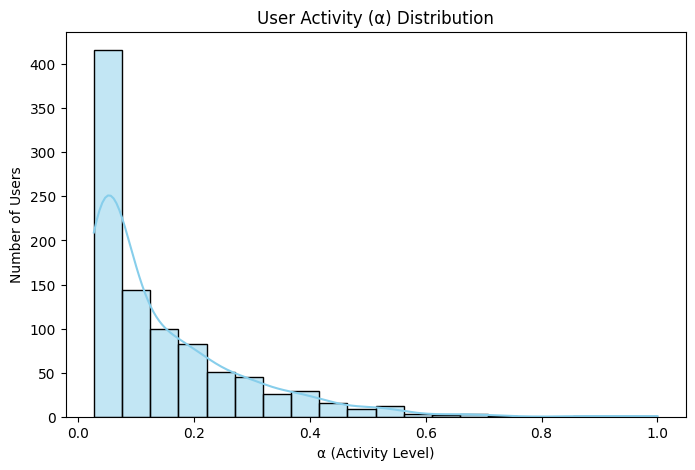

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(alpha_per_user, bins=20, kde=True, color="skyblue")
plt.title("User Activity (α) Distribution")
plt.xlabel("α (Activity Level)")
plt.ylabel("Number of Users")
plt.show()

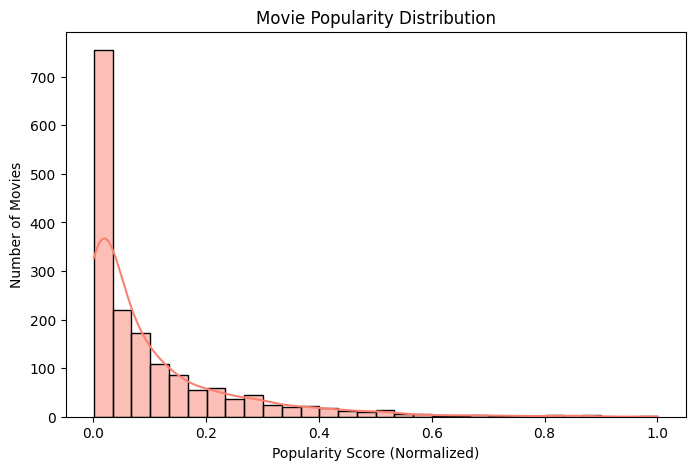

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(popular_movies["pop_score"], bins=30, kde=True, color="salmon")
plt.title("Movie Popularity Distribution")
plt.xlabel("Popularity Score (Normalized)")
plt.ylabel("Number of Movies")
plt.show()

C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_3884\2808512658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="movie_id", y="pop_score", data=top_10_popular, palette="viridis")


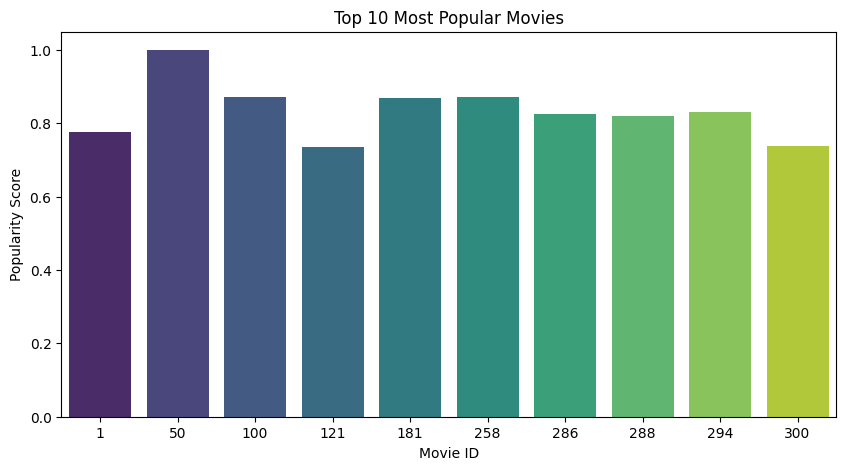

In [38]:
top_10_popular = popular_movies.sort_values("pop_score", ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x="movie_id", y="pop_score", data=top_10_popular, palette="viridis")
plt.title("Top 10 Most Popular Movies")
plt.xlabel("Movie ID")
plt.ylabel("Popularity Score")
plt.show()

week 4:hybrid recommender on a subset

In [39]:
# Take first 100 users and 100 movies for testing
subset_users = user_item_matrix.index[:100]
subset_movies = user_item_matrix.columns[:100]

test_user_item = user_item_matrix.loc[subset_users, subset_movies]

print("Subset shape:", test_user_item.shape)

Subset shape: (100, 100)


In [40]:
# Count ratings per user in subset
user_rating_counts = ratings[ratings.user_id.isin(subset_users)].groupby("user_id")["rating"].count()

# Normalize to [0,1] for adaptive alpha
adaptive_alpha_subset = user_rating_counts / user_rating_counts.max()

# Check first 10 users
adaptive_alpha_subset.head(10)

user_id
1     0.427673
2     0.097484
3     0.084906
4     0.037736
5     0.275157
6     0.331761
7     0.633648
8     0.092767
9     0.034591
10    0.289308
Name: rating, dtype: float64

In [41]:
# Count ratings per movie in subset
movie_counts = ratings[ratings.movie_id.isin(subset_movies)].groupby("movie_id")["rating"].count()

# Normalize popularity
pop_score_subset = movie_counts / movie_counts.max()

# Check top 5
pop_score_subset.sort_values(ascending=False).head()

movie_id
50     1.000000
100    0.871355
1      0.775300
56     0.675815
7      0.672384
Name: rating, dtype: float64

In [42]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Convert subset to sparse matrix
test_sparse = csr_matrix(test_user_item.values)

# Compute cosine similarity between users
user_sim_subset = cosine_similarity(test_sparse)

# Convert to DataFrame for easy access
user_sim_subset_df = pd.DataFrame(user_sim_subset,
                                  index=test_user_item.index,
                                  columns=test_user_item.index)

# Check first 5 rows
user_sim_subset_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.336798,0.0,0.133069,0.429268,0.590233,0.672988,0.350238,0.209762,0.560388,...,0.337114,0.774913,0.222475,0.770563,0.640190,0.431551,0.413845,0.191603,0.432052,0.0
2,0.336798,1.000000,0.0,0.346455,0.375243,0.441541,0.205458,0.163542,0.273065,0.315588,...,0.144100,0.286099,0.393214,0.222347,0.258250,0.340388,0.259984,0.231048,0.374814,0.0
3,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,0.133069,0.346455,0.0,1.000000,0.180938,0.153883,0.191133,0.425991,0.480592,0.291957,...,0.253614,0.219625,0.000000,0.225766,0.147570,0.213957,0.224299,0.000000,0.380578,0.0
5,0.429268,0.375243,0.0,0.180938,1.000000,0.379573,0.321905,0.222068,0.142610,0.327522,...,0.229534,0.466928,0.142610,0.418709,0.418192,0.387284,0.342774,0.203624,0.326248,0.0


In [43]:
def recommend_hybrid_subset(user_id, top_n=5, k=5):
    """
    Hybrid recommender for subset of users and movies.
    
    - Uses adaptive alpha per user
    - Combines CF and popularity
    """
    # Get adaptive alpha for user
    alpha = adaptive_alpha_subset.get(user_id, 0.5)
    
    # Top-k similar users
    similar_users = user_sim_subset_df[user_id].sort_values(ascending=False).iloc[1:k+1]
    
    # Compute CF scores
    cf_scores = test_user_item.loc[similar_users.index].T.dot(similar_users.values) / similar_users.values.sum()
    
    # Combine with popularity
    combined_scores = {}
    for movie in test_user_item.columns:
        pop_score = pop_score_subset.get(movie, 0)
        cf_score = cf_scores.get(movie, 0)
        combined_scores[movie] = alpha * cf_score + (1 - alpha) * pop_score
    
    # Remove already rated movies
    rated_movies = set(ratings[(ratings.user_id==user_id) & 
                               (ratings.movie_id.isin(test_user_item.columns))]["movie_id"])
    
    recommended = [(m,s) for m,s in combined_scores.items() if m not in rated_movies]
    
    # Sort and return top_n
    top_movies = [m for m,s in sorted(recommended, key=lambda x:x[1], reverse=True)[:top_n]]
    
    return top_movies

In [44]:
user_example = subset_users[0]
top_movies_subset = recommend_hybrid_subset(user_example, top_n=5, k=5)
print(f"Top 5 Hybrid Movies for User {user_example} (subset): {top_movies_subset}")

Top 5 Hybrid Movies for User 1 (subset): []


In [45]:
# User 1 rated movies in the subset
rated_subset = ratings[(ratings.user_id==user_example) & 
                       (ratings.movie_id.isin(test_user_item.columns))]["movie_id"]
print(f"Movies already rated by User {user_example} in subset:", list(rated_subset))

Movies already rated by User 1 in subset: [61, 33, 20, 47, 17, 90, 64, 92, 74, 98, 84, 31, 70, 60, 27, 82, 56, 80, 6, 49, 76, 72, 96, 81, 78, 51, 12, 14, 97, 44, 53, 85, 91, 10, 54, 24, 86, 39, 36, 23, 73, 67, 65, 100, 62, 69, 38, 9, 22, 21, 68, 89, 2, 30, 63, 32, 40, 93, 8, 99, 1, 75, 34, 26, 37, 71, 46, 41, 66, 77, 57, 50, 5, 87, 11, 35, 16, 79, 45, 48, 25, 4, 55, 42, 7, 43, 95, 58, 83, 3, 19, 29, 18, 59, 15, 52, 88, 13, 28, 94]


In [46]:
# Increase subset size
subset_users = user_item_matrix.index[:200]
subset_movies = user_item_matrix.columns[:300]

test_user_item = user_item_matrix.loc[subset_users, subset_movies]

print("New subset shape:", test_user_item.shape)

New subset shape: (200, 300)


In [47]:
# Recompute adaptive alpha
user_rating_counts = ratings[ratings.user_id.isin(subset_users)].groupby("user_id")["rating"].count()
adaptive_alpha_subset = user_rating_counts / user_rating_counts.max()

# Recompute movie popularity
movie_counts = ratings[ratings.movie_id.isin(subset_movies)].groupby("movie_id")["rating"].count()
pop_score_subset = movie_counts / movie_counts.max()

In [48]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

test_sparse = csr_matrix(test_user_item.values)
user_sim_subset = cosine_similarity(test_sparse)

user_sim_subset_df = pd.DataFrame(user_sim_subset,
                                  index=test_user_item.index,
                                  columns=test_user_item.index)

In [49]:
user_example = subset_users[0]
top_movies_subset = recommend_hybrid_subset(user_example, top_n=5, k=5)
print(f"Top 5 Hybrid Movies for User {user_example} (subset): {top_movies_subset}")

Top 5 Hybrid Movies for User 1 (subset): [288, 286, 276, 273, 285]


In [50]:
# Recompute adaptive alpha
user_rating_counts = ratings[ratings.user_id.isin(subset_users)].groupby("user_id")["rating"].count()
adaptive_alpha_subset = user_rating_counts / user_rating_counts.max()

print("Alpha computed ✔")

# Recompute movie popularity
movie_counts = ratings[ratings.movie_id.isin(subset_movies)].groupby("movie_id")["rating"].count()
pop_score_subset = movie_counts / movie_counts.max()

print("Popularity computed ✔")

Alpha computed ✔
Popularity computed ✔


In [51]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

test_sparse = csr_matrix(test_user_item.values)

user_sim_subset = cosine_similarity(test_sparse)

user_sim_subset_df = pd.DataFrame(
    user_sim_subset,
    index=test_user_item.index,
    columns=test_user_item.index
)

print("Similarity matrix computed ✔")

Similarity matrix computed ✔


In [52]:
user_example = subset_users[0]

top_movies_subset = recommend_hybrid_subset(user_example, top_n=5, k=5)

print(f"Top 5 Hybrid Movies for User {user_example} (subset): {top_movies_subset}")

Top 5 Hybrid Movies for User 1 (subset): [288, 286, 276, 273, 285]


Train and Test Split for Evaluation

In [53]:
from sklearn.model_selection import train_test_split

# Split ratings into train and test
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

Train size: (80000, 4)
Test size: (20000, 4)


In [54]:
# Create user-item matrix using ONLY train data
train_user_item = train_data.pivot(
    index="user_id",
    columns="movie_id",
    values="rating"
)


print("Train User-Item Matrix Shape:", train_user_item.shape)

Train User-Item Matrix Shape: (943, 1653)


In [55]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Replace NaN with 0 for similarity computation
train_user_item_filled = train_user_item.fillna(0)

# Convert to sparse matrix
train_sparse = csr_matrix(train_user_item_filled.values)

# Compute cosine similarity
train_user_similarity = cosine_similarity(train_sparse)

# Convert to DataFrame
train_user_similarity_df = pd.DataFrame(
    train_user_similarity,
    index=train_user_item.index,
    columns=train_user_item.index
)

print("Train similarity matrix computed ✔")

Train similarity matrix computed ✔


In [56]:
def recommend_train(user_id, top_n=5, k=5):
    
    # If user not in train set
    if user_id not in train_user_item.index:
        return []
    
    # Get similar users
    similar_users = train_user_similarity_df[user_id].sort_values(ascending=False).iloc[1:k+1]
    
    # Compute CF score
    user_ratings = train_user_item.fillna(0)
    
    cf_scores = user_ratings.loc[similar_users.index].T.dot(similar_users.values)
    
    # Normalize
    if similar_users.values.sum() != 0:
        cf_scores = cf_scores / similar_users.values.sum()
    
    # Movies already rated in train
    rated_movies = set(train_user_item.loc[user_id].dropna().index)
    
    # Remove already rated movies
    recommendations = [(movie, score) for movie, score in cf_scores.items()
                       if movie not in rated_movies]
    
    # Sort and return top N movie IDs
    top_movies = [movie for movie, score in sorted(recommendations,
                                                   key=lambda x: x[1],
                                                   reverse=True)[:top_n]]
    
    return top_movies

In [57]:
# Test for one user
test_user = 1

recommended_movies = recommend_train(test_user, top_n=5, k=5)

print("Recommended movies:", recommended_movies)


Recommended movies: [433, 357, 4, 100, 31]


In [58]:
#Evaluation Code (Full Subset Users)
import numpy as np

def evaluate_model(top_n=5, k=5):
    
    precisions = []
    recalls = []
    
    # Loop through users in train set
    for user in train_user_item.index:
        
        # Movies this user liked in test set
        test_movies = test_data[test_data.user_id == user]["movie_id"].tolist()
        
        if len(test_movies) == 0:
            continue  # skip users with no test data
        
        # Get recommendations
        recommended = recommend_train(user, top_n=top_n, k=k)
        
        if len(recommended) == 0:
            continue
        
        # Count relevant recommendations
        relevant = len(set(recommended) & set(test_movies))
        
        precision = relevant / top_n
        recall = relevant / len(test_movies)
        
        precisions.append(precision)
        recalls.append(recall)
    
    # Average metrics
    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    
    return avg_precision, avg_recall


# Run evaluation
precision, recall = evaluate_model(top_n=5, k=5)

print("Precision@5:", round(precision, 4))
print("Recall@5:", round(recall, 4))

Precision@5: 0.3019
Recall@5: 0.1019


Week-5:evaluate the Hybrid model (CF + Popularity) using the same train/test split.

In [59]:
# Compute movie popularity from TRAIN data only
train_movie_counts = train_data.groupby("movie_id")["rating"].count()

# Normalize popularity score
train_popularity = train_movie_counts / train_movie_counts.max()

print("Train popularity computed ✔")

Train popularity computed ✔


In [60]:
# Compute adaptive alpha using TRAIN data
train_user_counts = train_data.groupby("user_id")["rating"].count()

train_alpha = train_user_counts / train_user_counts.max()

print("Adaptive alpha computed ✔")

Adaptive alpha computed ✔


In [61]:
#hybrid Recommendation function using TRAIN data
def recommend_hybrid_train(user_id, top_n=5, k=5):
    
    # If user not in train set
    if user_id not in train_user_item.index:
        return []
    
    # Get adaptive alpha (default 0.5 if missing)
    alpha = train_alpha.get(user_id, 0.5)
    
    # Get top-k similar users
    similar_users = train_user_similarity_df[user_id].sort_values(ascending=False).iloc[1:k+1]
    
    user_ratings = train_user_item.fillna(0)
    
    # CF score
    cf_scores = user_ratings.loc[similar_users.index].T.dot(similar_users.values)
    
    if similar_users.values.sum() != 0:
        cf_scores = cf_scores / similar_users.values.sum()
    
    # Combine CF + Popularity
    combined_scores = {}
    
    for movie in train_user_item.columns:
        
        cf_score = cf_scores.get(movie, 0)
        pop_score = train_popularity.get(movie, 0)
        
        combined_scores[movie] = alpha * cf_score + (1 - alpha) * pop_score
    
    # Remove already rated movies (from train set)
    rated_movies = set(train_user_item.loc[user_id].dropna().index)
    
    recommendations = [(movie, score) for movie, score in combined_scores.items()
                       if movie not in rated_movies]
    
    # Sort and return top N
    top_movies = [movie for movie, score in sorted(recommendations,
                                                   key=lambda x: x[1],
                                                   reverse=True)[:top_n]]
    
    return top_movies

In [62]:
import numpy as np

def evaluate_hybrid(top_n=5, k=5):
    
    precisions = []
    recalls = []
    
    for user in train_user_item.index:
        
        # Movies this user has in test set
        test_movies = test_data[test_data.user_id == user]["movie_id"].tolist()
        
        if len(test_movies) == 0:
            continue
        
        # Get hybrid recommendations
        recommended = recommend_hybrid_train(user, top_n=top_n, k=k)
        
        if len(recommended) == 0:
            continue
        
        # Count relevant
        relevant = len(set(recommended) & set(test_movies))
        
        precision = relevant / top_n
        recall = relevant / len(test_movies)
        
        precisions.append(precision)
        recalls.append(recall)
    
    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    
    return avg_precision, avg_recall


# Run hybrid evaluation
hyb_precision, hyb_recall = evaluate_hybrid(top_n=5, k=5)

print("Hybrid Precision@5:", round(hyb_precision, 4))
print("Hybrid Recall@5:", round(hyb_recall, 4))

Hybrid Precision@5: 0.2968
Hybrid Recall@5: 0.0881


In [63]:
def compute_coverage_cf(top_n=5, k=5):
    
    recommended_movies = set()
    
    for user in train_user_item.index:
        recs = recommend_train(user, top_n=top_n, k=k)
        recommended_movies.update(recs)
    
    total_movies = len(train_user_item.columns)
    
    coverage = len(recommended_movies) / total_movies
    
    return coverage


cf_coverage = compute_coverage_cf(top_n=5, k=5)

print("CF Coverage:", round(cf_coverage, 4))

CF Coverage: 0.2626


In [64]:
def compute_coverage_hybrid(top_n=5, k=5):
    
    recommended_movies = set()
    
    for user in train_user_item.index:
        recs = recommend_hybrid_train(user, top_n=top_n, k=k)
        recommended_movies.update(recs)
    
    total_movies = len(train_user_item.columns)
    
    coverage = len(recommended_movies) / total_movies
    
    return coverage


hyb_coverage = compute_coverage_hybrid(top_n=5, k=5)

print("Hybrid Coverage:", round(hyb_coverage, 4))

Hybrid Coverage: 0.1149


In [65]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Transpose matrix (movies x users)
item_user_matrix = train_user_item.fillna(0).T

# Convert to sparse
item_sparse = csr_matrix(item_user_matrix.values)

# Compute item similarity
item_similarity = cosine_similarity(item_sparse)

# Convert to DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

print("Item similarity matrix computed ✔")

Item similarity matrix computed ✔


In [66]:
def recommend_item_based(user_id, top_n=5):
    
    # If user not in train set
    if user_id not in train_user_item.index:
        return []
    
    # Get user ratings (train only)
    user_ratings = train_user_item.loc[user_id].dropna()
    
    scores = {}
    
    # For each movie rated by user
    for movie, rating in user_ratings.items():
        
        # Get similarity scores for that movie
        similar_movies = item_similarity_df[movie]
        
        for sim_movie, similarity in similar_movies.items():
            
            if sim_movie == movie:
                continue
            
            # Weighted score
            scores[sim_movie] = scores.get(sim_movie, 0) + similarity * rating
    
    # Remove already rated movies
    rated_movies = set(user_ratings.index)
    
    recommendations = [(movie, score) for movie, score in scores.items()
                       if movie not in rated_movies]
    
    # Sort by score
    recommendations = sorted(recommendations,
                             key=lambda x: x[1],
                             reverse=True)
    
    top_movies = [movie for movie, score in recommendations[:top_n]]
    
    return top_movies

In [67]:
print("Item-Based Recommendations for User 1:",
      recommend_item_based(1, top_n=5))

Item-Based Recommendations for User 1: [204, 186, 423, 238, 181]


In [68]:
def evaluate_item_based(top_n=5):
    
    precisions = []
    recalls = []
    
    for user in train_user_item.index:
        
        # Get test movies for user
        test_movies = test_data[test_data.user_id == user]["movie_id"].tolist()
        
        if len(test_movies) == 0:
            continue
        
        # Get recommendations
        recommended = recommend_item_based(user, top_n=top_n)
        
        if len(recommended) == 0:
            continue
        
        # Count relevant
        relevant = len(set(recommended) & set(test_movies))
        
        precision = relevant / top_n
        recall = relevant / len(test_movies)
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.mean(precisions), np.mean(recalls)


# Run evaluation
item_precision, item_recall = evaluate_item_based(top_n=5)

print("Item-Based Precision@5:", round(item_precision, 4))
print("Item-Based Recall@5:", round(item_recall, 4))

Item-Based Precision@5: 0.3557
Item-Based Recall@5: 0.1215


In [69]:
def compute_coverage_item(top_n=5):
    
    recommended_movies = set()
    
    for user in train_user_item.index:
        recs = recommend_item_based(user, top_n=top_n)
        recommended_movies.update(recs)
    
    total_movies = len(train_user_item.columns)
    
    coverage = len(recommended_movies) / total_movies
    
    return coverage


item_coverage = compute_coverage_item(top_n=5)

print("Item-Based Coverage:", round(item_coverage, 4))

Item-Based Coverage: 0.0962


Week-6:Agentic AI Layer

In [70]:
def agent_recommender(user_id, top_n=5):
    
    # If user not in training data
    if user_id not in train_user_item.index:
        return []
    
    # Count how many ratings user has in train
    user_rating_count = train_data[train_data.user_id == user_id].shape[0]
    
    # Decision Logic
    if user_rating_count <= 5:
        model_used = "Popularity"
        # Recommend top popular movies not rated
        rated_movies = set(train_user_item.loc[user_id].dropna().index)
        popular_movies = train_popularity.sort_values(ascending=False).index
        recommendations = [m for m in popular_movies if m not in rated_movies][:top_n]
    
    elif user_rating_count <= 20:
        model_used = "Hybrid"
        recommendations = recommend_hybrid_train(user_id, top_n=top_n)
    
    else:
        model_used = "Item-Based"
        recommendations = recommend_item_based(user_id, top_n=top_n)
    
    return recommendations, model_used

In [71]:
recs, model = agent_recommender(1, top_n=5)

print("Agent selected model:", model)
print("Recommendations:", recs)

Agent selected model: Item-Based
Recommendations: [204, 186, 423, 238, 181]


In [72]:
def evaluate_agent(top_n=5):
    
    precisions = []
    recalls = []
    
    for user in train_user_item.index:
        
        test_movies = test_data[test_data.user_id == user]["movie_id"].tolist()
        
        if len(test_movies) == 0:
            continue
        
        recommended, _ = agent_recommender(user, top_n=top_n)
        
        if len(recommended) == 0:
            continue
        
        relevant = len(set(recommended) & set(test_movies))
        
        precision = relevant / top_n
        recall = relevant / len(test_movies)
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.mean(precisions), np.mean(recalls)


agent_precision, agent_recall = evaluate_agent(top_n=5)

print("Agent Precision@5:", round(agent_precision, 4))
print("Agent Recall@5:", round(agent_recall, 4))

Agent Precision@5: 0.3445
Agent Recall@5: 0.109


In [73]:
import numpy as np

def compute_diversity(model_function, top_n=5):
    
    diversities = []
    
    for user in train_user_item.index:
        
        recs = model_function(user, top_n=top_n)
        
        if len(recs) < 2:
            continue
        
        sim_sum = 0
        count = 0
        
        for i in range(len(recs)):
            for j in range(i+1, len(recs)):
                
                movie_i = recs[i]
                movie_j = recs[j]
                
                if movie_i in item_similarity_df.index and movie_j in item_similarity_df.index:
                    sim_sum += item_similarity_df.loc[movie_i, movie_j]
                    count += 1
        
        if count > 0:
            avg_similarity = sim_sum / count
            diversity = 1 - avg_similarity
            diversities.append(diversity)
    
    return np.mean(diversities)

In [74]:
item_diversity = compute_diversity(recommend_item_based, top_n=5)

print("Item-Based Diversity:", round(item_diversity, 4))

Item-Based Diversity: 0.512


In [75]:
def recommend_user_based_train(user_id, top_n=5):
    
    if user_id not in train_user_item.index:
        return []
    
    # Get similarity scores for this user
    user_similarities = user_similarity_df[user_id].sort_values(ascending=False)
    
    # Remove self
    user_similarities = user_similarities.drop(user_id)
    
    scores = {}
    
    # Take top 10 similar users
    top_similar_users = user_similarities.head(10)
    
    for similar_user, similarity in top_similar_users.items():
        
        similar_user_ratings = train_user_item.loc[similar_user].dropna()
        
        for movie, rating in similar_user_ratings.items():
            
            scores[movie] = scores.get(movie, 0) + similarity * rating
    
    # Remove movies already rated by target user
    rated_movies = set(train_user_item.loc[user_id].dropna().index)
    
    recommendations = [(movie, score) for movie, score in scores.items()
                       if movie not in rated_movies]
    
    recommendations = sorted(recommendations,
                             key=lambda x: x[1],
                             reverse=True)
    
    top_movies = [movie for movie, score in recommendations[:top_n]]
    
    return top_movies

In [76]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Replace NaN with 0 for similarity
train_user_item_filled = train_user_item.fillna(0)

# Compute cosine similarity
user_similarity = cosine_similarity(train_user_item_filled)

# Convert to DataFrame
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_user_item.index,
    columns=train_user_item.index
)

print("Train User Similarity Matrix Ready ✔")

Train User Similarity Matrix Ready ✔


In [77]:
user_diversity = compute_diversity(recommend_user_based_train, top_n=5)

print("User-Based Diversity:", round(user_diversity, 4))


User-Based Diversity: 0.6008


In [78]:
user_diversity = compute_diversity(recommend_user_based_train, top_n=5)

print("User-Based Diversity:", round(user_diversity, 4))

User-Based Diversity: 0.6008


In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
ratings = pd.read_csv(
    "../data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

# Train-test split (80-20)
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_ratings))
print("Test size:", len(test_ratings))

Train size: 80000
Test size: 20000


In [80]:
# Create user-item matrix from TRAIN data only
train_user_item = train_ratings.pivot(
    index="user_id",
    columns="movie_id",
    values="rating"
).fillna(0)

train_user_item.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1668,1670,1671,1672,1673,1676,1678,1679,1680,1681
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,3.0,4.0,0.0,3.0,0.0,4.0,0.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
import sys
sys.path.append("../recommendation")

from models.user_based import build_user_similarity, recommend_user_based
from models.item_based import build_item_similarity, recommend_item_based
from models.hybrid import compute_popularity, recommend_hybrid

In [82]:
# Build similarity matrices
user_similarity_df = build_user_similarity(train_user_item)
item_similarity_df = build_item_similarity(train_user_item)

# Popularity scores (from TRAIN only)
popularity_scores = compute_popularity(train_ratings)

print("Models built successfully.")

Models built successfully.


In [83]:
#precision @5
def precision_at_k(recommended, actual, k=5):
    """
    recommended: list of recommended movie_ids
    actual: set of actual movie_ids from test set
    """
    recommended_k = recommended[:k]
    
    if len(recommended_k) == 0:
        return 0
    
    relevant = len(set(recommended_k) & actual)
    return relevant / k

In [98]:
import numpy as np

def precision_recall_at_k(recommend_func, test_data, top_n=5):

    precisions = []
    recalls = []

    test_users = test_data["user_id"].unique()

    for user in test_users:

        relevant_items = test_data[
            test_data["user_id"] == user
        ]["movie_id"].tolist()

        if user not in train_user_item.index:
            continue

        recommended = recommend_func(user, top_n)

        if len(recommended) == 0:
            continue

        hits = len(set(recommended) & set(relevant_items))

        precision = hits / top_n
        recall = hits / len(relevant_items)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

In [99]:
import numpy as np

def evaluate_user_based(k=5):
    precisions = []

    # Evaluate only users that appear in BOTH train and test
    common_users = set(train_ratings.user_id.unique()) & set(test_ratings.user_id.unique())

    for user in list(common_users)[:200]:   # limit to 200 users for speed
        
        # Get actual movies from TEST set
        actual_movies = set(
            test_ratings[test_ratings.user_id == user]["movie_id"]
        )
        
        # Skip if no test movies
        if len(actual_movies) == 0:
            continue
        
        # Get recommendations
        recommended = recommend_user_based(
            user,
            train_user_item,
            user_similarity_df,
            top_n=k
        )
        
        prec = precision_at_k(recommended, actual_movies, k)
        precisions.append(prec)

    return np.mean(precisions)

In [85]:
evaluate_user_based(k=5)

np.float64(0.319)

In [86]:
def evaluate_item_based(k=5):
    precisions = []

    common_users = set(train_ratings.user_id.unique()) & set(test_ratings.user_id.unique())

    for user in list(common_users)[:200]:

        actual_movies = set(
            test_ratings[test_ratings.user_id == user]["movie_id"]
        )

        if len(actual_movies) == 0:
            continue

        recommended = recommend_item_based(
            user,
            train_user_item,
            item_similarity_df,
            top_n=k
        )

        prec = precision_at_k(recommended, actual_movies, k)
        precisions.append(prec)

    return np.mean(precisions)

In [100]:
def user_based_wrapper(user, top_n):
    return recommend_user_based(
        user,
        train_user_item,
        user_similarity_df,
        top_n=top_n
    )

def item_based_wrapper(user, top_n):
    return recommend_item_based(
        user,
        train_user_item,
        item_similarity_df,
        top_n=top_n
    )

In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split

ratings = pd.read_csv(
    "../data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

In [88]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_ratings))
print("Test:", len(test_ratings))

Train: 80000
Test: 20000


In [89]:
train_user_item = train_ratings.pivot(
    index="user_id",
    columns="movie_id",
    values="rating"
).fillna(0)


In [90]:
import sys
sys.path.append("../recommendation")

from models.user_based import build_user_similarity, recommend_user_based
from models.item_based import build_item_similarity, recommend_item_based

In [91]:
user_similarity_df = build_user_similarity(train_user_item)
item_similarity_df = build_item_similarity(train_user_item)

In [92]:
evaluate_item_based(k=5)

np.float64(0.336)

In [93]:
def evaluate_hybrid(k=5, alpha=0.7):
    precisions = []

    common_users = set(train_ratings.user_id.unique()) & set(test_ratings.user_id.unique())

    for user in list(common_users)[:200]:

        actual_movies = set(
            test_ratings[test_ratings.user_id == user]["movie_id"]
        )

        if len(actual_movies) == 0:
            continue

        # For hybrid we need CF scores
        cf_scores = train_user_item.loc[user]

        recommended = recommend_hybrid(
            user,
            train_user_item,
            cf_scores,
            popularity_scores,
            alpha=alpha,
            top_n=k
        )

        prec = precision_at_k(recommended, actual_movies, k)
        precisions.append(prec)

    return np.mean(precisions)

In [94]:
from models.hybrid import compute_popularity

popularity_scores = compute_popularity(train_ratings)

print("Popularity scores created.")

Popularity scores created.


In [95]:
evaluate_hybrid(k=5, alpha=0.7)

np.float64(0.001)

In [96]:
# -----------------------------
# Wrapper functions for evaluation
# -----------------------------

def user_based_wrapper(user, top_n):
    return recommend_user_based(
        user,
        train_user_item,
        user_similarity_df,
        top_n=top_n
    )

def item_based_wrapper(user, top_n):
    return recommend_item_based(
        user,
        train_user_item,
        item_similarity_df,
        top_n=top_n
    )

In [101]:
print("User-Based:", precision_recall_at_k(user_based_wrapper, test_ratings, top_n=5))
print("Item-Based:", precision_recall_at_k(item_based_wrapper, test_ratings, top_n=5))

User-Based: (np.float64(0.3423404255319149), np.float64(0.11597985291875978))
Item-Based: (np.float64(0.35574468085106387), np.float64(0.12149365877681716))
